# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LinearRegression

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [2]:
# 1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. 
df = pd.read_csv('./data/data.csv', delimiter=';')

# Filter on columns to the variables we'll actually use. 
X = df.loc[:, ['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment', 'Curricular units 1st sem (approved)']]

# Document how you handle any missing values. 
X.isna().sum() # no missing values

# For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.
df['Target'] = df['Target'].map({
    'Graduate': 'not dropout',
    'Enrolled': 'not dropout',
    'Dropout': 'dropout'
    }) # convert target to binary

In [3]:
# 2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. 
X_2 = df.loc[:, ['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']]
y = df['Target']

reg = LogisticRegression(max_iter=1000).fit(X_2, y)
# Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?
feature_naes = X_2.columns
coefs = reg.coef_[0]

summary = pd.DataFrame({
    'feature': feature_naes,
    'coef': coefs
})
print(summary)
print("Debtor and Age at enrollment predict a higher dropout probability, while Tuition fees up to date and Scholarship holder predict a lower dropout probability. " \
"\nBeing up to date on tuition seems to reduce dropout risk.")

                   feature      coef
0                   Debtor -0.530625
1  Tuition fees up to date  2.556542
2       Scholarship holder  1.227442
3        Age at enrollment -0.049925
Debtor and Age at enrollment predict a higher dropout probability, while Tuition fees up to date and Scholarship holder predict a lower dropout probability. 
Being up to date on tuition seems to reduce dropout risk.


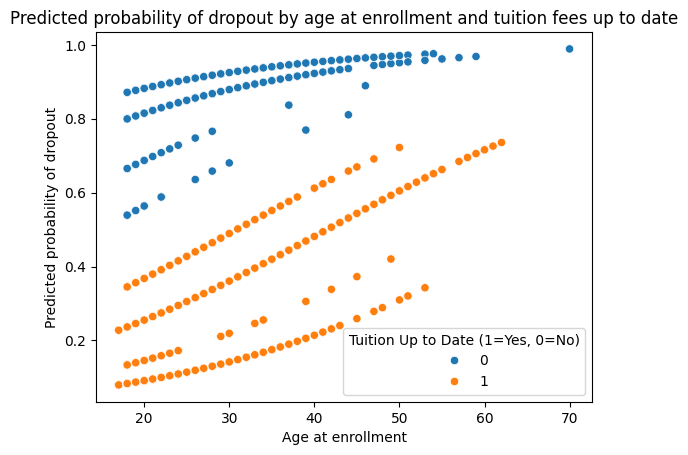


Dropout probability gap (not up to date minus up to date) by age group:
age_group
16-20    0.604
21-25    0.602
26-30    0.556
31-40    0.519
41+      0.409
Name: effect, dtype: float64
Average predicted dropout probability (tuition NOT up to date): 0.861
Average predicted dropout probability (tuition up to date):     0.248
Average reduction in dropout probability from being up to date: 0.613


/tmp/ipykernel_26830/2189375571.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  X_2.groupby(['age_group', 'Tuition fees up to date'])['dropout_prob']


In [4]:
# 3. Use `.predict_proba` and compute expected dropout probabilities. 
X_2['dropout_prob'] = reg.predict_proba(X_2)[:, 0] # get probabilities of dropout
# Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. 
sns.scatterplot(
    data=X_2,
    x='Age at enrollment', 
    y='dropout_prob', 
    hue='Tuition fees up to date'
)
plt.xlabel('Age at enrollment')
plt.ylabel('Predicted probability of dropout')
plt.title('Predicted probability of dropout by age at enrollment and tuition fees up to date')
plt.legend(title='Tuition Up to Date (1=Yes, 0=No)')
plt.show()
 
# For what ages does being up to date on tuition seem to reduce dropout probability the most? 
X_2['age_group'] = pd.cut(X_2['Age at enrollment'], bins=[15, 20, 25, 30, 40, 70], labels=['16-20', '21-25', '26-30', '31-40', '41+'])
age_tuition_effect = (
    X_2.groupby(['age_group', 'Tuition fees up to date'])['dropout_prob']
    .mean()
    .unstack()
    .assign(effect=lambda d: d[0] - d[1])
)
print("\nDropout probability gap (not up to date minus up to date) by age group:")
print(age_tuition_effect['effect'].round(3))

# On average, by how much does being up to date on tuition change the predicted probability of dropout?
avg_prob_by_tuition = X_2.groupby('Tuition fees up to date')['dropout_prob'].mean()
avg_effect = avg_prob_by_tuition[0] - avg_prob_by_tuition[1]
print(f"Average predicted dropout probability (tuition NOT up to date): {avg_prob_by_tuition[0]:.3f}")
print(f"Average predicted dropout probability (tuition up to date):     {avg_prob_by_tuition[1]:.3f}")
print(f"Average reduction in dropout probability from being up to date: {avg_effect:.3f}")

In [5]:
#4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?
X_2 = df.loc[:, ['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']]
reg = LogisticRegression(max_iter=1000).fit(X_2, y)

y_pred = reg.predict(X_2)
cm = confusion_matrix(y, y_pred)
print("Confusion Matrix:")
print(cm)
accuracy = (cm[0, 0] + cm[1, 1]) / np.sum(cm)
print(f"Accuracy: {accuracy:.3f}")

Confusion Matrix:
[[ 530  891]
 [ 162 2841]]
Accuracy: 0.762


In [6]:
y_binary = df['Target'].map({'dropout': 1, 'not dropout': 0})
reg_logistic = LogisticRegression(max_iter=1000).fit(X_2, y_binary)
logistic_probs = reg_logistic.predict_proba(X_2)[:, list(reg_logistic.classes_).index(1)]

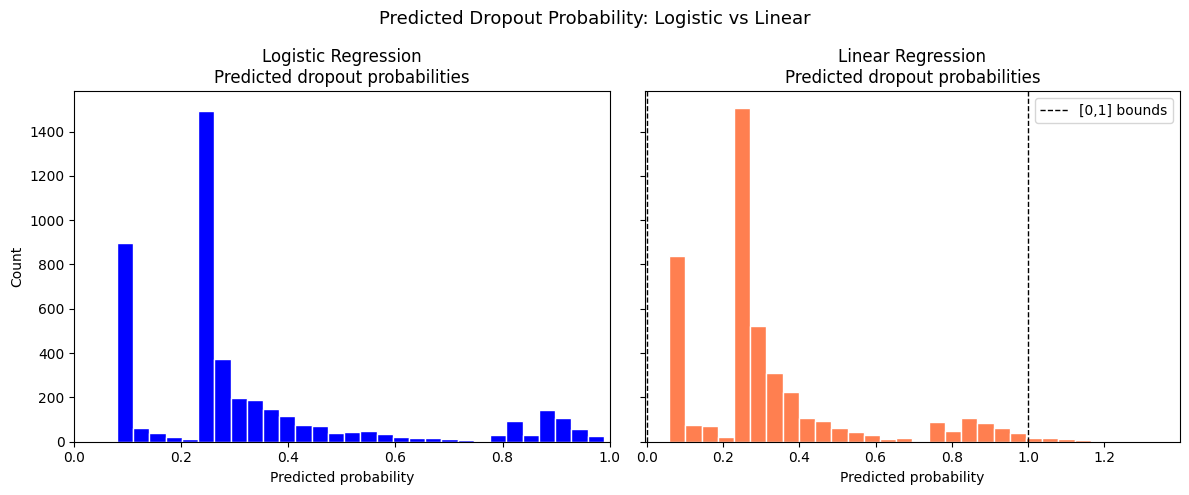

Linear model: 1.3% of predictions fall outside [0, 1]


In [7]:
# 5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. 
reg_linear = LinearRegression().fit(X_2, y_binary)
linear_probs = reg_linear.predict(X_2)

# Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].hist(logistic_probs, bins=30, color='blue', edgecolor='white')
axes[0].set_title('Logistic Regression\nPredicted dropout probabilities')
axes[0].set_xlabel('Predicted probability')
axes[0].set_ylabel('Count')
axes[0].set_xlim(0, 1)

axes[1].hist(linear_probs, bins=30, color='coral', edgecolor='white')
axes[1].set_title('Linear Regression\nPredicted dropout probabilities')
axes[1].set_xlabel('Predicted probability')

out_of_bounds = ((linear_probs < 0) | (linear_probs > 1)).mean()
axes[1].axvline(0, color='black', linestyle='--', linewidth=1, label='[0,1] bounds')
axes[1].axvline(1, color='black', linestyle='--', linewidth=1)
axes[1].legend()

plt.suptitle('Predicted Dropout Probability: Logistic vs Linear', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Linear model: {out_of_bounds:.1%} of predictions fall outside [0, 1]")

#  Logistic regression constrains all predictions to (0, 1). 
# The linear model will produce some predictions below 0 or above 1 for students at the extremes, those with very low or very high dropout risk

6. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

The highest-risk students are those who are debtors, not up to date on tuition, not scholarship holders, and older at enrollment. The most actionable intervention targets tuition status, since it had by far the largest coefficient. Interventions could include emergency financial aid or payment plan outreach triggered when a student falls behind on tuition, targeted scholarship programs for debtors, and early-warning systems that flag students matching this profile at enrollment.


Classes predicted (hard): ['Dropout', 'Graduate']
Classes in data:          ['Dropout', 'Enrolled', 'Graduate']


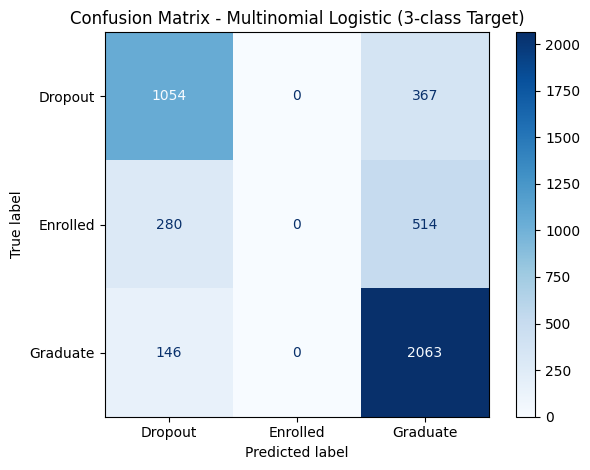


Accuracy: 0.705

Mean predicted probability per class:
P(Dropout)     0.321
P(Enrolled)    0.179
P(Graduate)    0.499
dtype: float64

Sample predicted probabilities (first 5 rows):
   P(Dropout)  P(Enrolled)  P(Graduate)
0       0.681        0.210        0.109
1       0.695        0.146        0.159
2       0.953        0.041        0.006
3       0.118        0.177        0.705
4       0.184        0.213        0.603

    - Hard classification with .predict will likely predict only the majority class (probably Graduate) and entirely miss Enrolled, since it's the smallest class. 
    - .predict_proba however will assign nonzero probability to all three classes for every student
      


In [8]:
# 7. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. 
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score

df_orig = pd.read_csv('./data/data.csv', delimiter=';')
y_multi = df_orig['Target']  # 'Graduate', 'Enrolled', 'Dropout'
X_6 = df.loc[:, ['Debtor', 'Tuition fees up to date', 
                  'Curricular units 1st sem (approved)']]
X_6 = df.loc[:, ['Debtor', 'Tuition fees up to date', 
                  'Curricular units 1st sem (approved)']]

reg_multi = LogisticRegression(max_iter=1000).fit(X_6, y_multi)

# Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. 
y_pred_multi = reg_multi.predict(X_6)
print("\nClasses predicted (hard):", sorted(set(y_pred_multi)))
print("Classes in data:         ", sorted(set(y_multi)))
cm_multi = confusion_matrix(y_multi, y_pred_multi, labels=reg_multi.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_multi, display_labels=reg_multi.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Multinomial Logistic (3-class Target)')
plt.tight_layout()
plt.show()

print(f"\nAccuracy: {accuracy_score(y_multi, y_pred_multi):.3f}")

# Use `.predict_proba` to predict probabilities instead and look at the values. 
proba_df = pd.DataFrame(
    reg_multi.predict_proba(X_6),
    columns=[f'P({c})' for c in reg_multi.classes_]
)
print("\nMean predicted probability per class:")
print(proba_df.mean().round(3))
print("\nSample predicted probabilities (first 5 rows):")
print(proba_df.head().round(3))

# Does your hard classification predict every class? Do your predicted probabilities predict every class?
print("""
    - Hard classification with .predict will likely predict only the majority class (probably Graduate) and entirely miss Enrolled, since it's the smallest class. 
    - .predict_proba however will assign nonzero probability to all three classes for every student
      """)

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class? 

In [9]:
# 1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.
df = pd.read_csv('./data/cirrhosis.csv')

# Filter to relevant columns
cols = ['Bilirubin', 'Edema', 'Drug', 'Stage', 'Status']
df = df[cols].copy()

# Document missing values
print("Missing values per column:")
print(df.isna().sum())

# Drop rows with missing values
df = df.dropna()
print(f"\nRows after dropping NAs: {len(df)}")

print(df.isna().sum())

# Encode target: alive = 1, dead = 0
df['Alive'] = df['Status'].map({'C': 1, 'CL': 1, 'D': 0})

Missing values per column:
Bilirubin      0
Edema          0
Drug         106
Stage          6
Status         0
dtype: int64

Rows after dropping NAs: 312
Bilirubin    0
Edema        0
Drug         0
Stage        0
Status       0
dtype: int64


In [10]:
# 2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. 

X_2 = pd.get_dummies(df[['Edema', 'Drug', 'Bilirubin']], drop_first=False)
# drop one dummy per group to avoid multicollinearity
X_2 = pd.get_dummies(df[['Edema', 'Drug', 'Bilirubin']], drop_first=True)
y = df['Alive']

reg2 = LogisticRegression(max_iter=1000).fit(X_2, y)

coef_df = pd.DataFrame({
    'feature': X_2.columns,
    'coef': reg2.coef_[0]
})
print("\nLogistic regression coefficients:")
print(coef_df.to_string(index=False))

# with drop_first=True:
#   Edema_S (vs N), Edema_Y (vs N), Drug_Placebo (vs D-penicillamine), Bilirubin
# Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? 
# How does survival rate vary with edema?
print("""
Interpretation:
- Drug_Placebo coef > 0 means placebo predicts higher survival than drug. drug does not improve survival
- Bilirubin coef < 0. higher bilirubin predicts lower survival rate
- Edema_S and Edema_Y coefs < 0. edema (especially Y) predicts lower survival vs no edema
""")


Logistic regression coefficients:
     feature      coef
   Bilirubin -0.351424
     Edema_S -0.450677
     Edema_Y -1.611049
Drug_Placebo  0.231225

Interpretation:
- Drug_Placebo coef > 0 means placebo predicts higher survival than drug. drug does not improve survival
- Bilirubin coef < 0. higher bilirubin predicts lower survival rate
- Edema_S and Edema_Y coefs < 0. edema (especially Y) predicts lower survival vs no edema



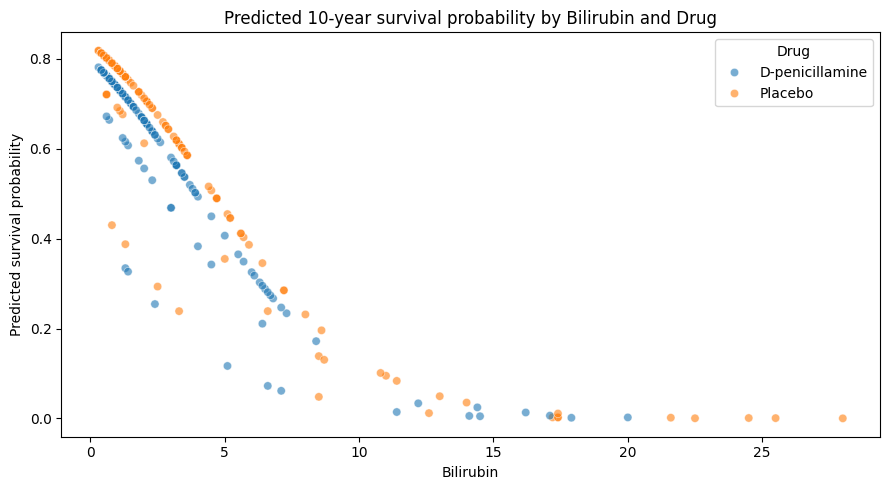

Average survival probability by drug:
Drug
D-penicillamine    0.590
Placebo            0.609
Name: survival_prob, dtype: float64

Average difference (drug minus placebo): -0.019


In [11]:
# 3. Use `.predict_proba` and compute expected surivival probabilities. 
df['survival_prob'] = reg2.predict_proba(X_2)[:, list(reg2.classes_).index(1)]

# Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`.
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=df, x='Bilirubin', y='survival_prob', hue='Drug',
                alpha=0.6, ax=ax)
ax.set_xlabel('Bilirubin')
ax.set_ylabel('Predicted survival probability')
ax.set_title('Predicted 10-year survival probability by Bilirubin and Drug')
plt.tight_layout()
plt.show() 

# For what values of `Bilirubin` does the drug seem to increase patient survival rate? 
# On average, by how much do patients who take the drug increase their probability of survival?

avg_by_drug = df.groupby('Drug')['survival_prob'].mean()
drug_effect = avg_by_drug['D-penicillamine'] - avg_by_drug['Placebo']
print("Average survival probability by drug:")
print(avg_by_drug.round(3))
print(f"\nAverage difference (drug minus placebo): {drug_effect:.3f}")


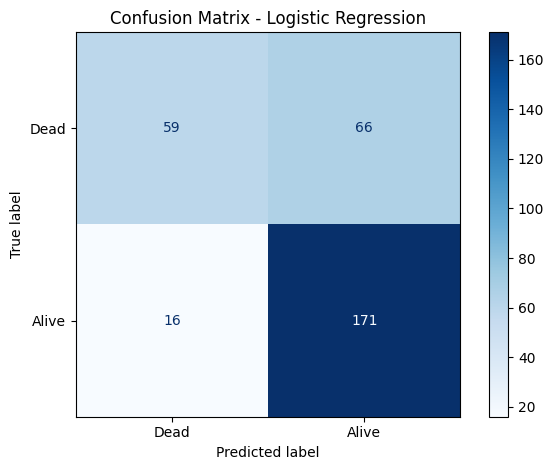


Accuracy: 0.737


In [12]:
# 4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?
df['predicted'] = reg2.predict(X_2)

cm = confusion_matrix(y, df['predicted'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dead', 'Alive'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.show()

print(f"\nAccuracy: {accuracy_score(y, df['predicted']):.3f}")


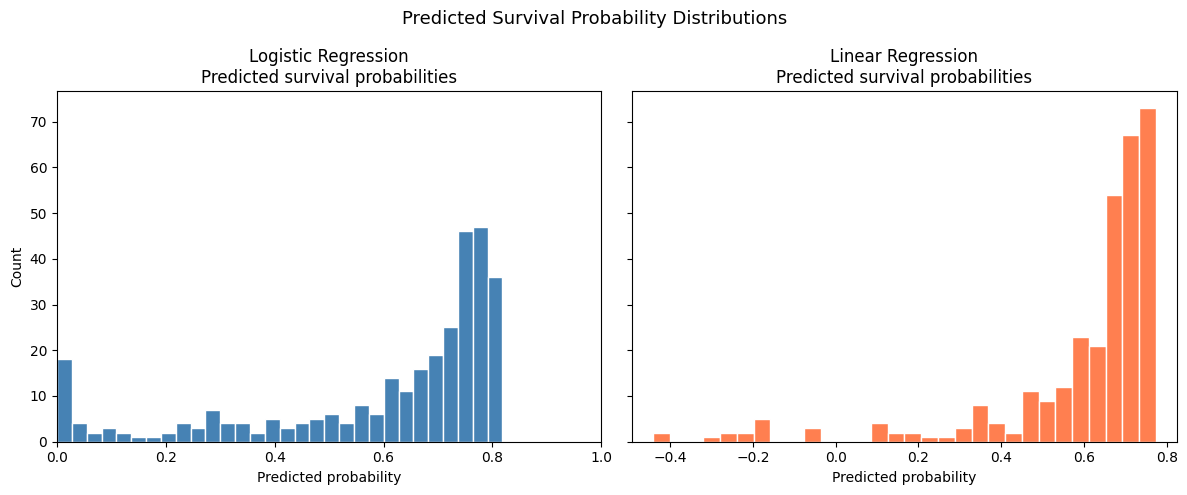


Linear model: 4.8% of predictions fall outside [0, 1]

Comparison:
      Logistic regression predictions are bounded to (0, 1). Linear regression will produce predictions outside this range for extreme bilirubin values. 
      The histogram will show the linear model's distribution extending past 0 or 1, which is why logistic regression is preferred for binary outcomes.
      


In [13]:
# 5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. 
lin = LinearRegression().fit(X_2, y)
df['survival_prob_linear'] = lin.predict(X_2)

# Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].hist(df['survival_prob'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Logistic Regression\nPredicted survival probabilities')
axes[0].set_xlabel('Predicted probability')
axes[0].set_ylabel('Count')
axes[0].set_xlim(0, 1)

axes[1].hist(df['survival_prob_linear'], bins=30, color='coral', edgecolor='white')
axes[1].set_title('Linear Regression\nPredicted survival probabilities')
axes[1].set_xlabel('Predicted probability')
axes[1].set_xlim(df['survival_prob_linear'].min() - 0.05, 
                  df['survival_prob_linear'].max() + 0.05)

plt.suptitle('Predicted Survival Probability Distributions', fontsize=13)
plt.tight_layout()
plt.show()

pct_out_of_bounds = ((df['survival_prob_linear'] < 0) | 
                      (df['survival_prob_linear'] > 1)).mean()
print(f"\nLinear model: {pct_out_of_bounds:.1%} of predictions fall outside [0, 1]")

print("""
Comparison:
      Logistic regression predictions are bounded to (0, 1). Linear regression will produce predictions outside this range for extreme bilirubin values. 
      The histogram will show the linear model's distribution extending past 0 or 1, which is why logistic regression is preferred for binary outcomes.
      """)


Stages predicted (hard classification): [np.int64(3), np.int64(4)]
Actual stages present:                  [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


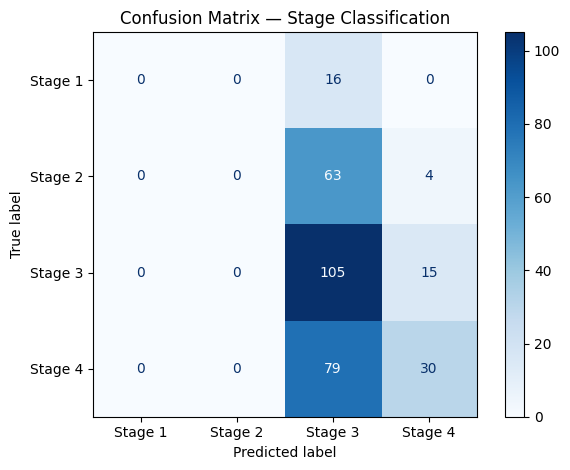


Mean predicted probability per stage:
P(Stage 1)    0.051
P(Stage 2)    0.215
P(Stage 3)    0.385
P(Stage 4)    0.349
dtype: float64

Sample of predicted probabilities (first 5 rows):
   P(Stage 1)  P(Stage 2)  P(Stage 3)  P(Stage 4)
0       0.000       0.033       0.144       0.824
1       0.072       0.252       0.398       0.279
2       0.029       0.182       0.396       0.394
3       0.023       0.177       0.397       0.403
4       0.020       0.225       0.423       0.331

Hard classification with .predict will predict only Stage 3 or 4 (the majority classes) and miss Stages 1 and 2. 
However, .predict_proba will assign nonzero probability to every stage 
      


In [15]:
# 6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. 
X_6 = pd.get_dummies(df[['Edema', 'Bilirubin']], drop_first=True)
y_6 = df['Stage'].astype(int)

reg6 = LogisticRegression(max_iter=1000).fit(X_6, y_6)

# Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. 
# Hard classification
df['stage_pred'] = reg6.predict(X_6)
print("\nStages predicted (hard classification):", sorted(df['stage_pred'].unique()))
print("Actual stages present:                 ", sorted(y_6.unique()))

cm6 = confusion_matrix(y_6, df['stage_pred'])
disp6 = ConfusionMatrixDisplay(confusion_matrix=cm6, 
                                display_labels=[f'Stage {i}' for i in reg6.classes_])
disp6.plot(cmap='Blues')
plt.title('Confusion Matrix — Stage Classification')
plt.tight_layout()
plt.show()

# Use `.predict_proba` to predict probabilities instead and look at the values. 
# Predicted probabilities
stage_probs = pd.DataFrame(
    reg6.predict_proba(X_6),
    columns=[f'P(Stage {c})' for c in reg6.classes_]
)
print("\nMean predicted probability per stage:")
print(stage_probs.mean().round(3))
print("\nSample of predicted probabilities (first 5 rows):")
print(stage_probs.head().round(3))

# Does your hard classification predict every class? Do your predicted probabilities predict every class? 
print("""
Hard classification with .predict will predict only Stage 3 or 4 (the majority classes) and miss Stages 1 and 2. 
However, .predict_proba will assign nonzero probability to every stage 
      """)


**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?


The derivative is just $b_k$. For a 1-unit change in $x_k$, the prediction changes by exactly $b_k$,
regardless of the values of any other features.


2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?


Derivative:

$$\frac{\partial \hat{p}}{\partial x_k} = \frac{\partial}{\partial L}\frac{e^L}{1+e^L} \cdot \frac{\partial L}{\partial x_k} = \frac{e^L}{(1+e^L)^2} \cdot b_k = \hat{p}(1-\hat{p}) \cdot b_k$$

Unlike the linear case, the derivative depends on $x$ through $\hat{p}$. The effect of a 1-unit change
in $x_k$ is not constant and it varies with the current predicted probability. The coefficient $b_k$ scales
an effect that is largest when $\hat{p} = 0.5$ and shrinks toward zero as $\hat{p} \to 0$ or $\hat{p} \to 1$.


At $\hat{p} = 0.5$: $\hat{p}(1-\hat{p}) = 0.25$, so:

$$\frac{\partial \hat{p}}{\partial x_k} \approx 0.25 \cdot b_k = \frac{b_k}{4}$$

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio? 

$$\log\left(\frac{\hat{p}}{1-\hat{p}}\right) = b \cdot x = b_0 + b_1 x_1 + \cdots + b_K x_K$$

Taking the derivative with respect to $x_k$:

$$\frac{\partial}{\partial x_k}\log\left(\frac{\hat{p}}{1-\hat{p}}\right) = b_k$$

A 1-unit change in $x_k$ changes the log odds ratio by exactly $b_k$, regardless of $x$, just like
the linear model.
